In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import iqr
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

RANDOM_STATE = 43

np.random.seed(RANDOM_STATE)

raw = pd.read_csv("../data/raw/diamonds.csv")
assert not any(raw.isna().any())  # Нет пропущенных значений

row_count = len(raw)

# Удаляем дубликаты
raw.drop_duplicates(inplace=True)
print(f"{row_count - len(raw)} дубликатов удалено")

# Работаем с логарифмами цен
raw["price"] = np.log10(raw["price"])

NUMERIC_COLS = ["carat", "depth", "table", "x", "y", "z"]

# В датасете сказано, что категории имеют значение именно в этом порядке.
# Будем использовать OrdinalEncoder, который будет соблюдать этот порядок.
CUT_CATEGORIES = ["Ideal", "Premium", "Very Good", "Good", "Fair"]
COLOR_CATEGORIES = ["J", "I", "H", "G", "F", "E", "D"]
CLARITY_CATEGORIES = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

pipeline = Pipeline(
    [
        (
            "column",
            ColumnTransformer(
                transformers=[
                    (
                        "1",
                        Pipeline(
                            [("impute", SimpleImputer()), ("scale", StandardScaler())]
                        ),
                        NUMERIC_COLS,
                    ),
                    ("2", OrdinalEncoder(categories=[CUT_CATEGORIES]), ["cut"]),
                    ("3", OrdinalEncoder(categories=[COLOR_CATEGORIES]), ["color"]),
                    ("4", OrdinalEncoder(categories=[CLARITY_CATEGORIES]), ["clarity"]),
                ]
            ),
        ),
        ("linear", LinearRegression()),
    ]
)

X_raw = raw.drop("price", axis=1)
y_raw = raw["price"]

# Делим на тренировочную, валидационную и на тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=RANDOM_STATE
)

pipeline.fit(X_train, y_train)

126 дубликатов удалено


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('1', ...), ('2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

Хотелось бы видеть RMSE отдельно для "дешёвых" алмазов и для "дорогих", а ещё построить график зависимости относительной ошибки от истинного значения на тестовой выборке.

In [ ]:
less_than_1000_usd_diamonds = y_test < np.log10(1000)
more_than_1000_usd_diamonds = y_test >= np.log10(1000)

print(
    f"Train RMSE = {root_mean_squared_error(y_train, pipeline.predict(X_train))}\n"
    f"Val RMSE (на всех алмазах) = {root_mean_squared_error(y_val, pipeline.predict(X_val))}\n"
    f"Test RMSE (на всех алмазах) = {root_mean_squared_error(y_test, pipeline.predict(X_test))}\n"
    f"Test RMSE (цена алмаза >= $1,000) = {
        root_mean_squared_error(
            y_test[more_than_1000_usd_diamonds],
            pipeline.predict(X_test[more_than_1000_usd_diamonds]))}\n"
    f"Test RMSE (цена алмаза < $1,000) = {
        root_mean_squared_error(
            y_test[less_than_1000_usd_diamonds],
            pipeline.predict(X_test[less_than_1000_usd_diamonds]))}"
)

Train RMSE = 0.0797257506384467
Val RMSE (на всех алмазах) = 0.08560449387786707
Test RMSE (на всех алмазах) = 0.08045837691206585
Test RMSE (цена алмаза >= $1,000) = 0.08660762811534713
Test RMSE (цена алмаза < $1,000) = 0.06129251761192657


На тестовой выборке для алмазов с ценой > $1000:
$$ 10^{RMSE_{over 1000}} = 10^{0.09} \approx 1.23 $$
то есть, показатель RMSE для логарифма цен можно сравнить с ошибкой в 23% от изначальной стоимости алмаза.

На тестовой выборке для алмазов с ценой < $1000:
$$ 10^{RMSE_{less than 1000}} = 10^{0.065} \approx 1.16 $$

то есть, показатель RMSE для логарифма цен можно сравнить с ошибкой в 16% от изначальной стоимости алмаза.


Сделаем сводную таблицу средних значений интересных нам метрик, а также построим графики абсолютных и относительных ошибок для логарифмированных цен и цен в изначальном пространстве (не лог-пространстве)

Средние значения по колонкам:


log10_true                    3.376133
log10_abs_error               0.051384
log10_relative_error          0.015295
original_true              3895.626767
original_abs_error          512.237133
original_relative_error       0.119487
dtype: float64

График "истинное значение/абсолютная ошибка" (для log10 price):


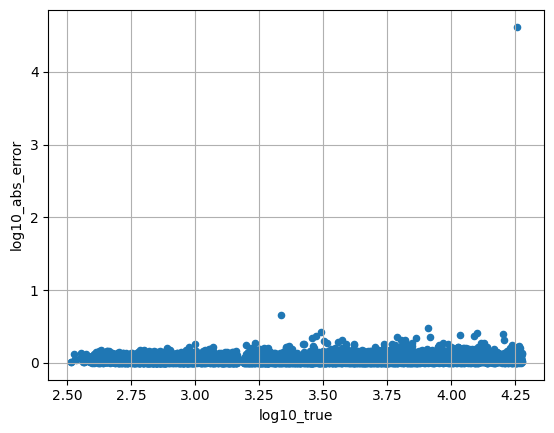

График "истинное значение/относительная ошибка" (для log10 price):


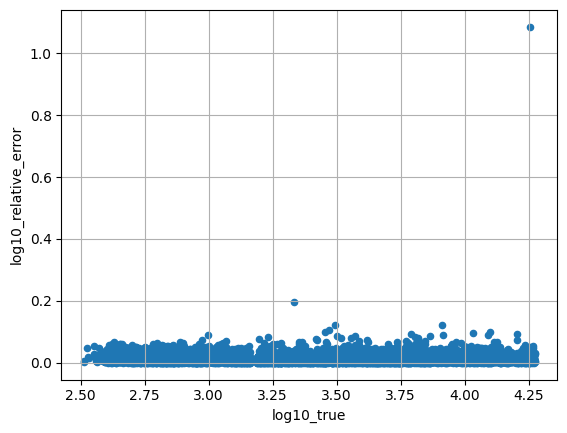

График "истинное значение/абсолютная ошибка":


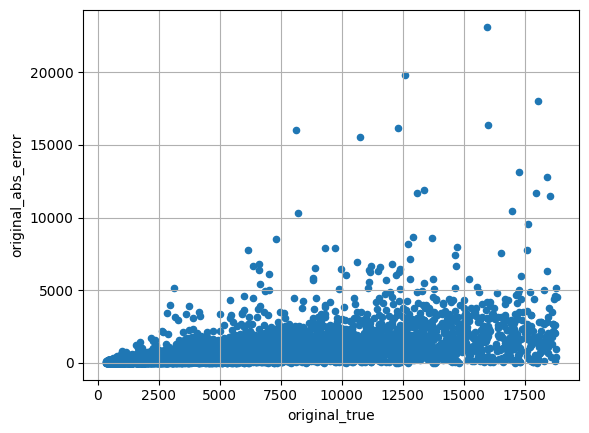

График "истинное значение/относительная ошибка":


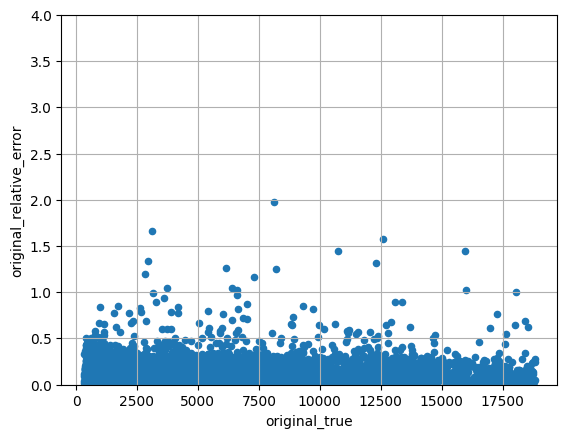

In [77]:
from IPython.display import display

pred_true = pd.DataFrame()
pred_true["log10_true"] = y_test
pred_true["log10_abs_error"] = np.abs(
    pipeline.predict(X_test) - pred_true["log10_true"]
)
pred_true["log10_relative_error"] = (
    pred_true["log10_abs_error"] / pred_true["log10_true"]
)

pred_true["original_true"] = 10**y_test
pred_true["original_abs_error"] = np.abs(
    10 ** pipeline.predict(X_test) - pred_true["original_true"]
)
pred_true["original_relative_error"] = (
    pred_true["original_abs_error"] / pred_true["original_true"]
)

print("Средние значения по колонкам:")
display(pred_true.mean())

print('График "истинное значение/абсолютная ошибка" (для log10 price):')
pred_true.plot(kind="scatter", y="log10_abs_error", x="log10_true", grid=True)
plt.show()
print('График "истинное значение/относительная ошибка" (для log10 price):')
pred_true.plot(kind="scatter", y="log10_relative_error", x="log10_true", grid=True)
plt.show()
print('График "истинное значение/абсолютная ошибка":')
pred_true.plot(kind="scatter", y="original_abs_error", x="original_true", grid=True)
plt.show()
print('График "истинное значение/относительная ошибка":')
pred_true.plot(
    kind="scatter", y="original_relative_error", x="original_true", grid=True,
    ylim=(0, 4)
)
plt.show()